In [1]:
import cv2
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.mixture import GaussianMixture

In [2]:
import sys
print(sys.executable)

/Users/nonscop/Desktop/sem5/CV/Chinczyk/chinczyk_venv/bin/python


In [3]:
def imshow(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

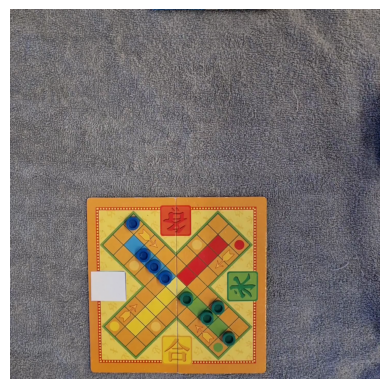

In [4]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture("data/vid_3_dist=1.mp4")

frame_number = 3000  # the frame you want
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

ret, frame = cap.read()  # read the frame
if not ret:
    cap.release()
    raise RuntimeError(f"Could not read frame {frame_number}")

cap.release()  # release after reading

# Convert BGR → RGB for display
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

In [5]:
# def nothing(x):
#     pass

# cv2.namedWindow("mask")
# cv2.createTrackbar("H min", "mask", 0, 179, nothing)
# cv2.createTrackbar("H max", "mask", 179, 179, nothing)
# cv2.createTrackbar("S min", "mask", 0, 255, nothing)
# cv2.createTrackbar("S max", "mask", 255, 255, nothing)
# cv2.createTrackbar("V min", "mask", 0, 255, nothing)
# cv2.createTrackbar("V max", "mask", 255, 255, nothing)

# while True:
#     h_min = cv2.getTrackbarPos("H min", "mask")
#     h_max = cv2.getTrackbarPos("H max", "mask")
#     s_min = cv2.getTrackbarPos("S min", "mask")
#     s_max = cv2.getTrackbarPos("S max", "mask")
#     v_min = cv2.getTrackbarPos("V min", "mask")
#     v_max = cv2.getTrackbarPos("V max", "mask")

#     lower = np.array([h_min, s_min, v_min])
#     upper = np.array([h_max, s_max, v_max])
#     mask = cv2.inRange(img_hsv, lower, upper)

#     cv2.imshow("mask", mask)
#     if cv2.waitKey(1) & 0xFF == 27:  # ESC to exit
#         break

# cv2.destroyAllWindows()

(np.float64(-0.5), np.float64(1439.5), np.float64(1439.5), np.float64(-0.5))

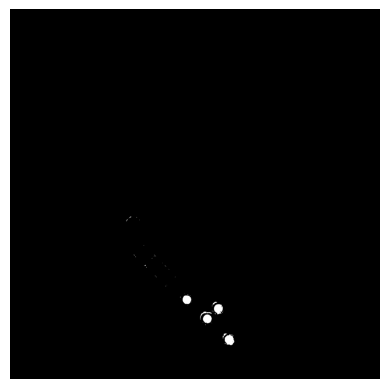

In [6]:
# img loaded via matplotlib -> RGB
img_rgb = frame_rgb.copy()

# Convert to HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Red color ranges (two ranges!)
lower_green1 = np.array([80, 100, 0])
upper_green1 = np.array([100, 255, 80])

mask1 = cv2.inRange(img_hsv, lower_green1, upper_green1)

green_mask = mask1

plt.imshow(green_mask, cmap="gray")
plt.axis("off")

Pawn centers (x, y): [(np.float64(687.9140625), np.float64(1130.8839285714287)), (np.float64(810.6649899396378), np.float64(1166.5482897384306)), (np.float64(767.6156424581005), np.float64(1205.4)), (np.float64(853.681981981982), np.float64(1287.7045045045045))]


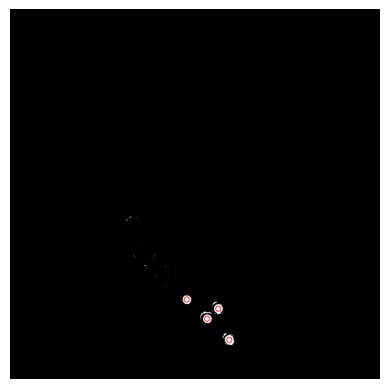

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Assume green_mask is cleaned binary mask
mask = green_mask.copy()

# Connected components (or contours)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

pawn_centers = []

for i in range(1, num_labels):  # skip background label 0
    x, y, w, h, area = stats[i]
    cx, cy = centroids[i]
    
    # Filter by area (adjust min_area depending on pawn size)
    min_area = 500
    max_area = 2000
    if area < min_area or area > max_area:
        continue
    
    # Optional: filter by approximate circularity
    circularity = 4 * np.pi * (area / (w * h))
    if circularity < 0.5:  # 1 = perfect circle, <0.5 = very elongated
        continue
    
    pawn_centers.append((cx, cy))

print("Pawn centers (x, y):", pawn_centers)

# Visualize
img_vis = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
for x, y in pawn_centers:
    cv2.circle(img_vis, (int(x), int(y)), 10, (255, 0, 0), 2)

plt.imshow(img_vis)
plt.axis("off")
plt.show()

In [39]:
import cv2
import numpy as np
from tqdm import tqdm

cap = cv2.VideoCapture("data/vid_3_dist=1.mp4")

# Video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
output_writer = cv2.VideoWriter("green_pawns_marked.mp4", fourcc, fps, (width, height))

for _ in tqdm(range(total_frames), desc="Processing video"):
    ret, frame = cap.read()
    if not ret:
        break
        
    mask_green = find_green_pawns(frame)

    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_green)
    pawn_centers_green = []

    for i in range(1, num_labels):  # skip background
        x, y, w, h, area = stats[i]
        cx, cy = centroids[i]
        min_area = 500
        if area < min_area:
            continue
            
        pawn_centers_green.append((cx, cy))

    mask_blue = find_blue_pawns(frame)

    # Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_blue)
    pawn_centers_blue = []

    for i in range(1, num_labels):  # skip background
        x, y, w, h, area = stats[i]
        cx, cy = centroids[i]
        min_area = 500
        if area < min_area:
            continue
            
        pawn_centers_blue.append((cx, cy))

    # Draw detected pawns
    output_frame = cv2.cvtColor(mask_green+mask_blue, cv2.COLOR_GRAY2BGR)
    for cx, cy in pawn_centers_green:
        cv2.circle(output_frame, (int(cx), int(cy)), 15, (255, 255, 51), 2)
        
    for cx, cy in pawn_centers_blue:
        cv2.circle(output_frame, (int(cx), int(cy)), 15, (0, 0, 255), 2)

    output_writer.write(output_frame)

cap.release()
output_writer.release()
print("Finished writing video: green_pawns_marked.mp4")

Processing video: 100%|████████████████████████████████████████████████████████████████████████████| 6447/6447 [02:19<00:00, 46.17it/s]

Finished writing video: green_pawns_marked.mp4


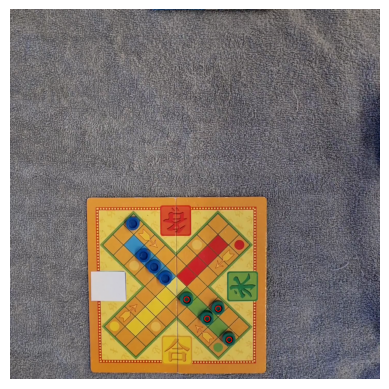

In [30]:
img_vis = img_rgb.copy()

for x, y in pawn_centers:
    cv2.circle(img_vis, (int(x), int(y)), 10, (255, 0, 0), 2)  # red circles

plt.imshow(img_vis)
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(1439.5), np.float64(1439.5), np.float64(-0.5))

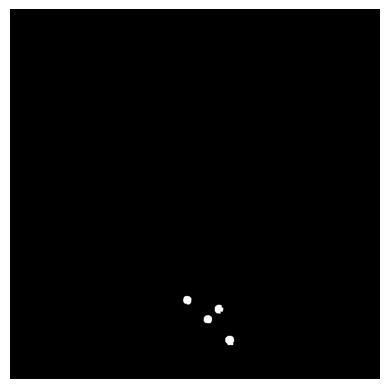

In [31]:
# Structuring element
kernel = np.ones((10, 10), np.uint8)  # adjust size to pawn scale

# 1) Opening: remove small noise
green_clean = cv2.morphologyEx(
    green_mask,
    cv2.MORPH_OPEN,
    kernel
)

# 2) Closing: fill gaps inside green regions
green_closed = cv2.morphologyEx(
    green_clean,
    cv2.MORPH_CLOSE,
    kernel
)

# Visualize
plt.imshow(green_closed, cmap="gray")
plt.axis("off")

(np.float64(-0.5), np.float64(1439.5), np.float64(1439.5), np.float64(-0.5))

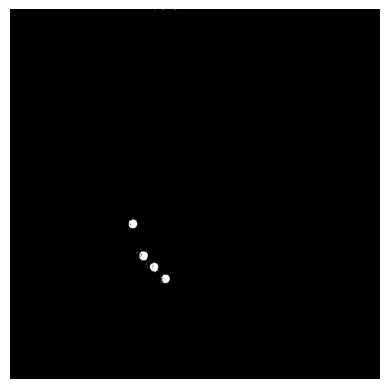

In [32]:
# Blue color range
lower_blue = np.array([108, 200, 60])
upper_blue = np.array([120, 255, 130])

blue_mask = cv2.inRange(img_hsv, lower_blue, upper_blue)

# Display
plt.imshow(blue_mask, cmap="gray")
plt.axis("off")

(np.float64(-0.5), np.float64(1439.5), np.float64(1439.5), np.float64(-0.5))

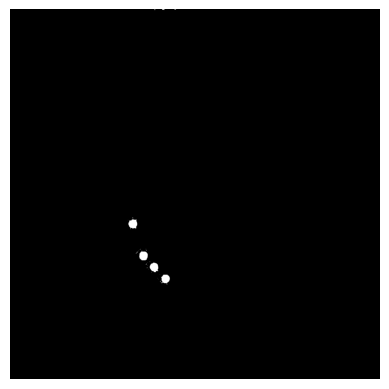

In [33]:
# Structuring element
kernel = np.ones((5, 5), np.uint8)  # adjust size to pawn scale

# 2) Closing: fill gaps inside green regions
blue_closed = cv2.morphologyEx(
    blue_mask,
    cv2.MORPH_CLOSE,
    kernel
)

# Visualize
plt.imshow(blue_closed, cmap="gray")
plt.axis("off")

In [35]:
def find_green_pawns(frame_bgr):
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    lower_green = np.array([80, 100, 0])
    upper_green = np.array([100, 255, 80])

    green_mask = cv2.inRange(frame_hsv, lower_green, upper_green)

    kernel = np.ones((5, 5), np.uint8)

    green_open = cv2.morphologyEx(green_mask, cv2.MORPH_OPEN, kernel)
    green_closed = cv2.morphologyEx(green_open, cv2.MORPH_CLOSE, kernel)

    return green_mask


def find_blue_pawns(frame_bgr):
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([108, 200, 60])
    upper_blue = np.array([120, 255, 130])

    blue_mask = cv2.inRange(frame_hsv, lower_blue, upper_blue)

    kernel = np.ones((5, 5), np.uint8)

    blue_open = cv2.morphologyEx(blue_mask, cv2.MORPH_OPEN, kernel)
    blue_closed = cv2.morphologyEx(blue_open, cv2.MORPH_CLOSE, kernel)

    return blue_mask

In [35]:
cap = cv2.VideoCapture("data/vid_2_dist=1.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

green_writer = cv2.VideoWriter(
    "green_masks.mp4", fourcc, fps, (width, height)
)

blue_writer = cv2.VideoWriter(
    "blue_masks.mp4", fourcc, fps, (width, height)
)

for _ in tqdm(range(total_frames), desc="Processing video"):
    ret, frame = cap.read()
    if not ret:
        break

    green_mask = find_green_pawns(frame)
    blue_mask = find_blue_pawns(frame)

    green_bgr = cv2.cvtColor(green_mask, cv2.COLOR_GRAY2BGR)
    blue_bgr = cv2.cvtColor(blue_mask, cv2.COLOR_GRAY2BGR)

    green_writer.write(green_bgr)
    blue_writer.write(blue_bgr)

cap.release()
green_writer.release()
blue_writer.release()

Processing video:   0%|          | 0/5881 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [39]:
import cv2
import numpy as np
from tqdm.std import tqdm  # terminal-friendly tqdm

def find_blue_pawns(frame_rgb):
    """Return binary mask of blue pawns"""
    frame_hsv = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2HSV)
    lower_blue = np.array([108, 200, 60])
    upper_blue = np.array([120, 255, 130])
    blue_mask = cv2.inRange(frame_hsv, lower_blue, upper_blue)

    # Morphology to remove noise / clean mask
    kernel = np.ones((15, 15), np.uint8)
    clean_mask = cv2.morphologyEx(blue_mask, cv2.MORPH_OPEN, kernel)
    kernel = np.ones((5, 5), np.uint8)
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_OPEN, kernel)

    return clean_mask

# Open video
cap = cv2.VideoCapture("data/vid_2_dist=1.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
blue_writer = cv2.VideoWriter("blue_pawns_marked.mp4", fourcc, fps, (width, height))

for _ in tqdm(range(total_frames), desc="Processing video"):
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    blue_mask = find_blue_pawns(frame_rgb)

    # Detect circles
    circles = cv2.HoughCircles(
        blue_mask,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=50,
        param1=50,
        param2=15,
        minRadius=5,
        maxRadius=50
    )

    output = frame.copy()
    if circles is not None:
        circles = np.uint16(np.around(circles[0]))
        for x, y, r in circles:
            cv2.circle(output, (x, y), r, (0, 0, 255), 2)  # outer circle in red
            cv2.circle(output, (x, y), 5, (0, 0, 255), 3)  # center dot

    blue_writer.write(output)

cap.release()
blue_writer.release()

Processing video: 100%|████████████████████████████████████████████████████████████████████████████| 5881/5881 [02:21<00:00, 41.63it/s]


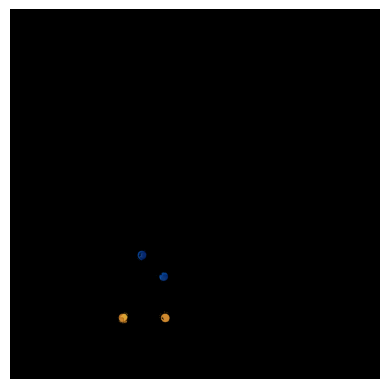

In [37]:
# blue_mask is uint8 (0 or 255)
masked_img = cv2.bitwise_and(img_hsv, img_hsv, mask=blue_mask)

# Display (convert back to RGB if needed)
plt.imshow(cv2.cvtColor(masked_img, cv2.COLOR_HSV2RGB))
plt.axis("off")
plt.show()

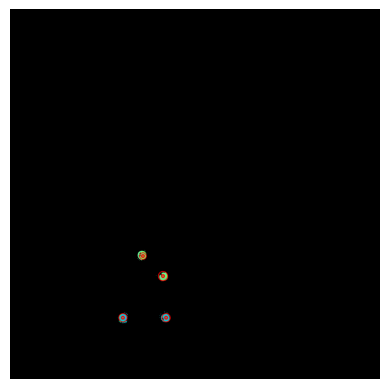

In [38]:
# Ensure single-channel 8-bit image
gray_mask = blue_mask.copy()
if gray_mask.dtype != np.uint8:
    gray_mask = gray_mask.astype(np.uint8)
    
kernel = np.ones((15, 15), np.uint8)  # adjust depending on noise size

# Remove small noise without filling gaps
gray_mask = cv2.morphologyEx(gray_mask, cv2.MORPH_OPEN, kernel)

# Optional: clean mask
kernel = np.ones((5,5), np.uint8)
gray_mask = cv2.morphologyEx(gray_mask, cv2.MORPH_CLOSE, kernel)
gray_mask = cv2.morphologyEx(gray_mask, cv2.MORPH_OPEN, kernel)

# Detect circles
circles = cv2.HoughCircles(
    gray_mask,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=50,
    param1=50,
    param2=15,
    minRadius=5,
    maxRadius=50
)

# Draw circles if found
output = masked_img.copy()
if circles is not None:
    circles = np.uint16(np.around(circles[0]))
    for x, y, r in circles:
        cv2.circle(output, (x, y), r, (255, 0, 0), 2)
        cv2.circle(output, (x, y), 5, (255, 0, 0), 3)

import matplotlib.pyplot as plt
plt.imshow(output)
plt.axis("off")
plt.show()

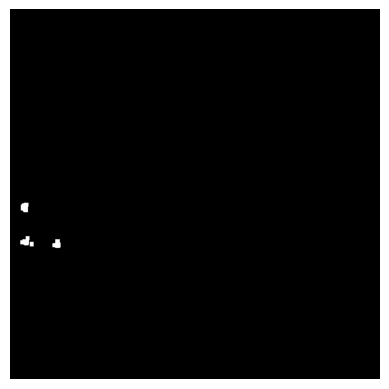

In [10]:
import cv2
import numpy as np

kernel = np.ones((15, 15), np.uint8)  # adjust depending on noise size

# Remove small noise without filling gaps
mask_clean = cv2.morphologyEx(gray_mask, cv2.MORPH_OPEN, kernel)

imshow(mask_clean)

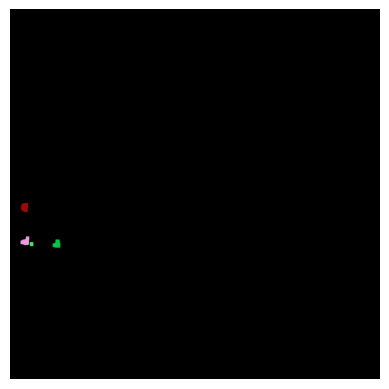

In [11]:
import cv2
import numpy as np

# mask_clean should be binary (0 or 255)
# Convert to uint8 if necessary
mask_uint8 = mask_clean.copy().astype(np.uint8)

# 1. Compute distance transform
dist = cv2.distanceTransform(mask_uint8, cv2.DIST_L2, 5)

# 2. Normalize for visualization (optional)
dist_vis = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)
imshow((dist_vis*255).astype(np.uint8))

# 3. Find peaks (sure foreground)
ret, sure_fg = cv2.threshold(dist, 0.5*dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# 4. Find unknown region
sure_bg = cv2.dilate(mask_uint8, np.ones((5,5), np.uint8), iterations=3)
unknown = cv2.subtract(sure_bg, sure_fg)

# 5. Marker labeling
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1  # so background is 1 instead of 0
markers[unknown==255] = 0

# 6. Apply watershed
mask_bgr = cv2.cvtColor(mask_uint8, cv2.COLOR_GRAY2BGR)  # dummy BGR image
cv2.watershed(mask_bgr, markers)

# markers now contains:
#  -1: boundary between objects
#  2,3,...: separated pawns

# Visualize separated pawns
output = np.zeros_like(mask_bgr)
for label in np.unique(markers):
    if label <= 1:  # skip background
        continue
    output[markers==label] = np.random.randint(0,255,3)

imshow(output)

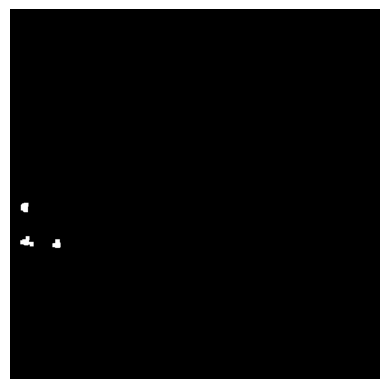

In [12]:
imshow(gray_mask)

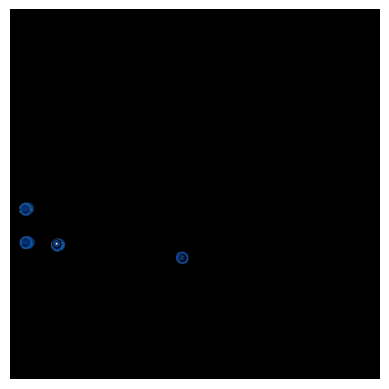

In [13]:
output = masked_img.copy()  # or frame_rgb.copy()

for x, y, r in circles:
    cv2.circle(output, (x, y), r, (0, 255, 0), 2)  # green outline
    cv2.circle(output, (x, y), 2, (0, 0, 255), 3)  # center dot

plt.imshow(cv2.cvtColor(output, cv2.COLOR_HSV2RGB))
plt.axis("off")
plt.show()

In [14]:
imshow(binary_mask)

NameError: name 'binary_mask' is not defined

(np.float64(-0.5), np.float64(1439.5), np.float64(1439.5), np.float64(-0.5))

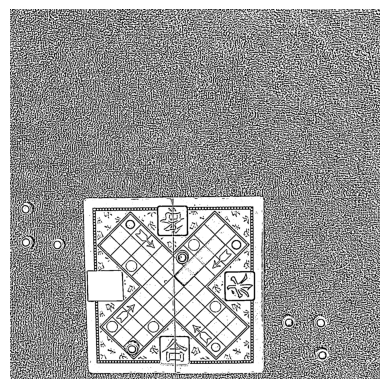

In [15]:
# Convert to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Optional but strongly recommended: denoise
gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Adaptive thresholding
th = cv2.adaptiveThreshold(
    gray_blur,
    maxValue=255,
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,  # or MEAN_C
    thresholdType=cv2.THRESH_BINARY,                # or THRESH_BINARY_INV
    blockSize=11,                                   # must be odd
    C=2                                             # constant subtracted from mean
)

# Visualization
plt.imshow(th, cmap="gray")
plt.axis("off")


(np.float64(-0.5), np.float64(1439.5), np.float64(1439.5), np.float64(-0.5))

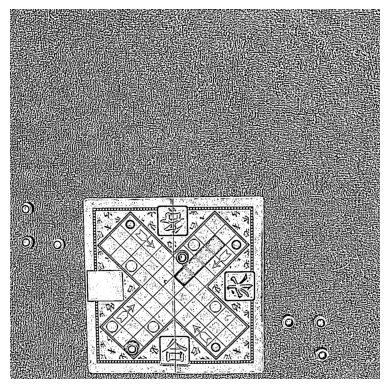

In [16]:
# Convert to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Optional but strongly recommended: denoise
gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Adaptive thresholding
th = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11, 2
)


# Visualization
plt.imshow(th, cmap="gray")
plt.axis("off")


(np.float64(-0.5), np.float64(1439.5), np.float64(1439.5), np.float64(-0.5))

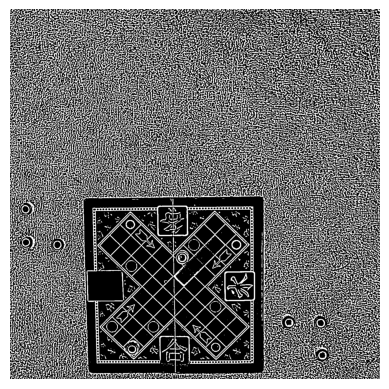

In [17]:
# Convert to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Optional but strongly recommended: denoise
gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Adaptive thresholding
th = cv2.adaptiveThreshold(
    gray_blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15, 3
)

# Visualization
plt.imshow(th, cmap="gray")
plt.axis("off")


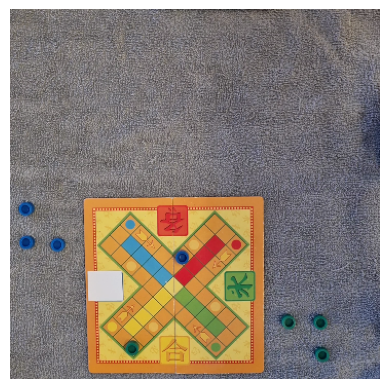

In [18]:
def imshow(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

ludo = frame.copy()
ludo = cv2.resize(ludo, None, fx=0.25, fy=0.25)
imshow(ludo)

In [19]:
# ludo_hsv = cv2.cvtColor(ludo, cv2.COLOR_BGR2HSV)
# pixels = ludo_hsv.reshape(-1, 3).astype(np.float32)

In [20]:
pixels = ludo.reshape(-1, 3).astype(np.float32)

In [21]:
n_components = 9
gmm = GaussianMixture(
    n_components=n_components,
    covariance_type="full",
    random_state=42
)

gmm.fit(pixels)

,"n_components n_components: int, default=1The number of mixture components.",9
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [22]:
labels = gmm.predict(pixels)

In [23]:
cluster_colors = np.zeros((n_components, 3), dtype=np.float32)

for i in range(n_components):
    cluster_colors[i] = pixels[labels == i].mean(axis=0)

segmented_pixels = cluster_colors[labels]
segmented = segmented_pixels.reshape(ludo.shape).astype(np.uint8)

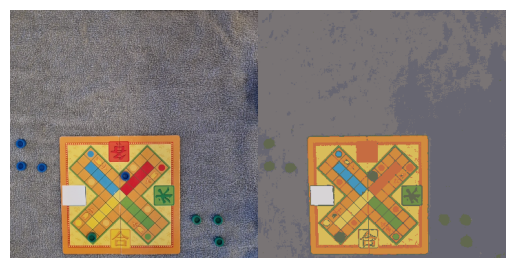

In [24]:
imshow(np.hstack([ludo, segmented]))

(np.float64(-0.5), np.float64(359.5), np.float64(359.5), np.float64(-0.5))

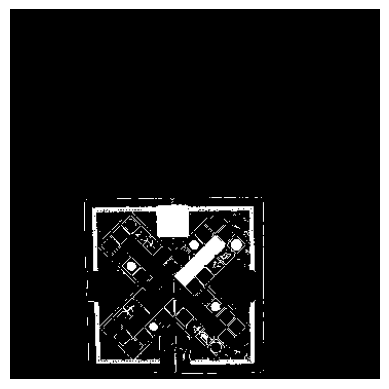

In [25]:
# find cluster closest to red
red_ref = np.array([0, 0, 255], dtype=np.float32)  # BGR
distances = np.linalg.norm(cluster_colors - red_ref, axis=1)
red_cluster = np.argmin(distances)

red_mask = (labels == red_cluster).reshape(ludo.shape[:2])

plt.imshow(red_mask, cmap="gray")
plt.axis("off")

In [26]:
ludo = frame.copy()

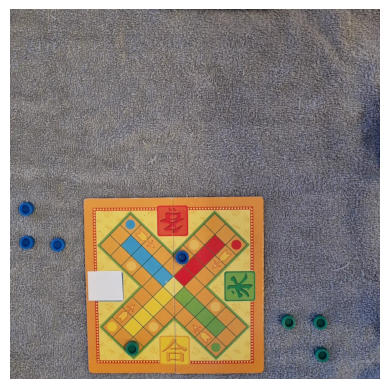

In [27]:
imshow(ludo)

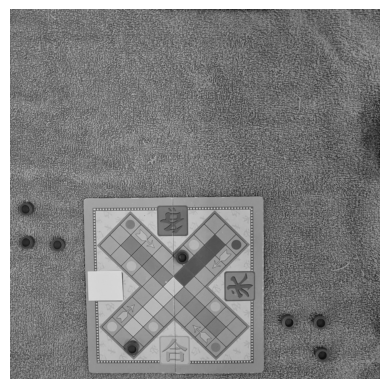

In [28]:
ludo_gray = cv2.cvtColor(ludo, cv2.COLOR_BGR2GRAY)
imshow(ludo_gray)

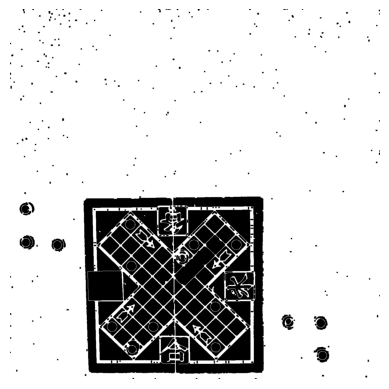

In [29]:
high, _ = cv2.threshold(
    ludo_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
low = 0.5 * high

ludo_canny = cv2.Canny(ludo_gray, low, high, apertureSize=3)

# Stronger morphology than CLEVR
ludo_canny = cv2.morphologyEx(
    ludo_canny,
    cv2.MORPH_CLOSE,
    kernel=np.ones((5, 5), np.uint8)
)

imshow(ludo_canny)


In [30]:
regions = np.zeros(ludo_canny.shape[:2], np.int32)
neighbours = [(-1, 0), (1, 0), (0, -1), (0, 1)]

In [31]:
def find_neighbours(img, y, x):
    c_neighbours = []
    for dy, dx in neighbours:
        ny, nx = y + dy, x + dx

        if ny < 0 or ny >= img.shape[0] or nx < 0 or nx >= img.shape[1]:
            continue

        if regions[ny, nx] > 0:
            continue

        if img[ny, nx] == 255:
            continue

        # uniformity test (binary here)
        if img[y, x] == img[ny, nx]:
            c_neighbours.append((ny, nx))

    return c_neighbours

def grow_region(img, y, x, cls):
    regions[y, x] = cls
    c_neighbours = find_neighbours(img, y, x)

    for ny, nx in c_neighbours:
        regions[ny, nx] = cls

    while c_neighbours:
        new_neighbours = []
        for ny, nx in c_neighbours:
            nn = find_neighbours(img, ny, nx)
            for _ny, _nx in nn:
                regions[_ny, _nx] = cls
            new_neighbours.extend(nn)
        c_neighbours = new_neighbours

In [32]:
cls = 1
for y in range(ludo_canny.shape[0]):
    for x in range(ludo_canny.shape[1]):
        if regions[y, x] == 0 and ludo_canny[y, x] == 0:
            grow_region(ludo_canny, y, x, cls)
            cls += 1


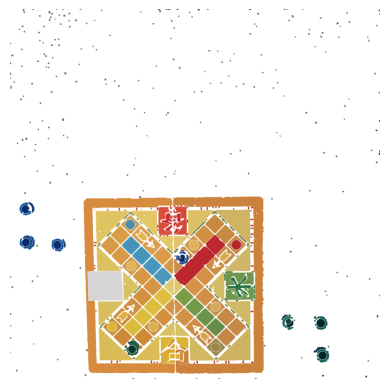

In [33]:
mean_colors = np.stack(
    [
        np.array([255, 255, 255])
        if j == 0
        else ludo[regions == j].mean(0)
        for j in range(cls)
    ],
    axis=0,
)

regions_colors = np.take(mean_colors, regions, axis=0)
regions_colors = regions_colors.astype(np.uint8)

imshow(regions_colors)


In [34]:
kernel = np.ones((5, 5), np.uint8)
edges = cv2.dilate(ludo_canny, kernel, iterations=1)

ret, labels = cv2.connectedComponents(255 - edges)


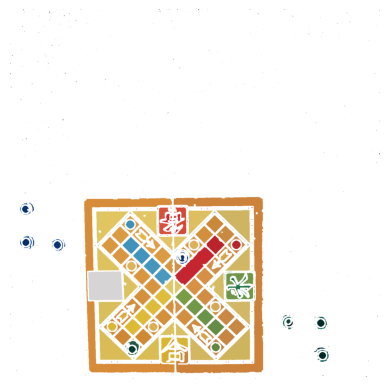

In [35]:
mean_colors = np.stack(
    [
        np.array([255, 255, 255])
        if j == 0
        else ludo[labels == j].mean(0)
        for j in range(ret)
    ],
    axis=0,
)

segmented = np.take(mean_colors, labels, axis=0).astype(np.uint8)
imshow(segmented)


In [36]:
import numpy as np

# Number of regions (cls already contains the next unused label)
num_regions = cls

# Generate a random color for each region
rng = np.random.default_rng(seed=42)  # fixed seed for reproducibility
colors = rng.integers(0, 255, size=(num_regions, 3), dtype=np.uint8)

# Optional: make background white
colors[0] = np.array([255, 255, 255], dtype=np.uint8)

In [37]:
# regions contains integer labels per pixel
regions_colored = colors[regions]

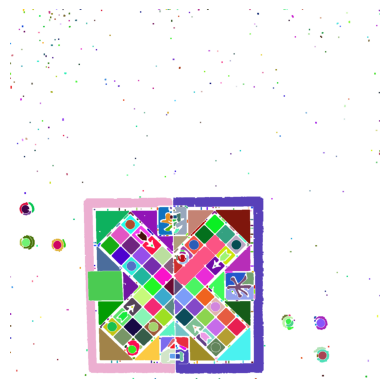

In [38]:
imshow(regions_colored)